In [1]:
import rasterio
import os
import subprocess
import matplotlib.pyplot as plt

import sys
sys.path.append('..')
from importlib import reload
import utils
reload(utils)


<module 'utils' from '/n/home10/erolf/tree_mapping/process_data/../utils.py'>

In [2]:
DATA_DIR = '../data'

### This Notebook processes data layers to align to the coarsest resolution of data available.
1. The first step is to aggregate the individuals tifs into one tif per site (if you don't already have that file)
2. The second step coarsens data to the resolution of a target image tif.
   - aggregation takes the average value of cells that are not nodata

## 1. merge lidar data by site, at 1m and 10m resolution
By running `python merge_lidar_by_site.py`
The following code plots the results.

In [3]:
merged_lidar_dir_1m = os.path.join(DATA_DIR, 'raw','lidar_by_site_32736')
processed_tif_fns = os.listdir(merged_lidar_dir_1m)
processed_tif_fps = [os.path.join(merged_lidar_dir_1m, x) for x in processed_tif_fns]
print(f'We have lidar data at 1m resolution for {len(processed_tif_fps)} sites') 

plot_raw_lidar = False
if plot_raw_lidar:
    for processed_site_tif in processed_tif_fps:
        fig, ax = plt.subplots()
        with rasterio.open(processed_site_tif) as f:
            d = f.read()

        plt.imshow(d[0], vmin=0, vmax=15, interpolation='none')

We have lidar data at 1m resolution for 15 sites


EPSG:32736
BoundingBox(left=400658.0, bottom=7286046.0, right=405393.0, top=7290881.0)
EPSG:32736
BoundingBox(left=400658.0, bottom=7286041.0, right=405398.0, top=7290881.0)
(484, 474)


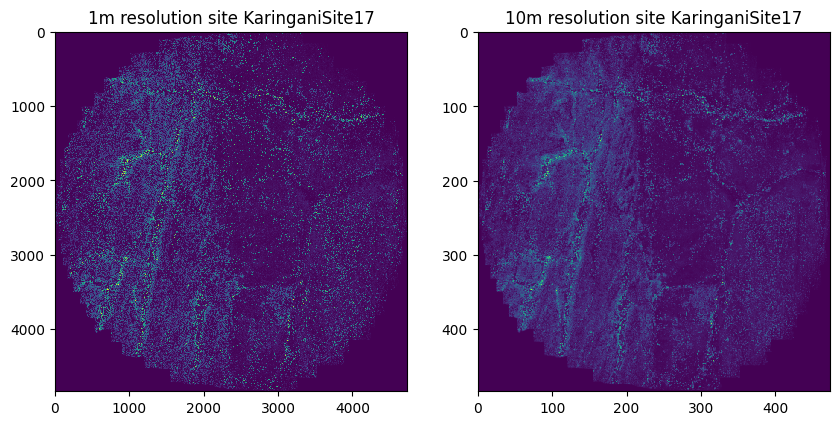

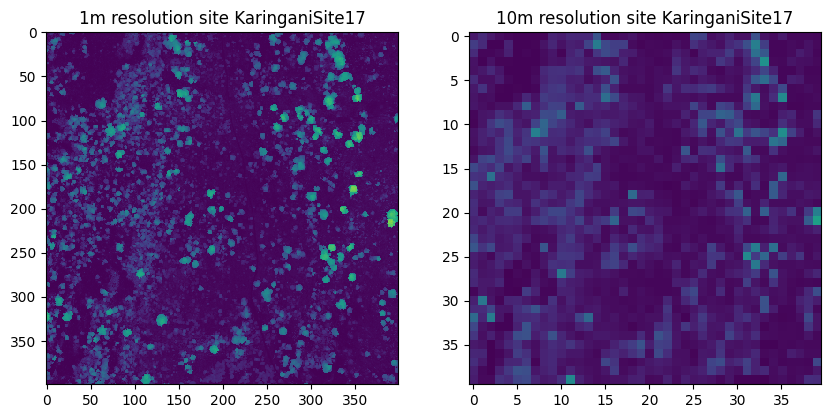

In [34]:
example_site = 'KaringaniSite17'

fn_1m = f'../data/raw/lidar_by_site_32736/{example_site}_CHM_1m_merged.tif'
with rasterio.open(fn_1m) as f:
    print(f.crs)
    print(f.bounds)
    d1 = f.read()
    
fn_10m = f'../data/int/lidar/lidar_by_site_32736_10m/{example_site}_CHM_10m.tif'
with rasterio.open(fn_10m) as f:
    print(f.crs)
    print(f.bounds)
    print(f.shape)
    d2 = f.read()
    
fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(d1[0], interpolation='none', vmin=0, vmax=15)
ax[1].imshow(d2[0], interpolation='none', vmin=0, vmax=15)
ax[0].set_title(f'1m resolution site {example_site}')
ax[1].set_title(f'10m resolution site {example_site}')

fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(d1[0, 2000:2400, 2000:2400], interpolation='none', vmin=0, vmax=15)
ax[1].imshow(d2[0, 200:240, 200:240], interpolation='none', vmin=0, vmax=15)
ax[0].set_title(f'1m resolution site {example_site}')
ax[1].set_title(f'10m resolution site {example_site}');

## 1. crop sentinel data, at  10m resolution
By running `process_Karinani_sites.sh`
The following code plots the results.

In [25]:
fn_img = f'../data/raw/sentinel/S2A_MSIL2A_20230418T073611_R092_T36KVU_20230419T022704/T36KVU_20230418T073611_TCI_10m.tif'
#tree_mapping/data/int/sentinel/sentinel_by_site_32736_10m/KaringaniSite17/T36KUU_20230413T073619_TCI_10m.tif
with rasterio.open(fn_img) as f:
    print(f.res)
    print(f.crs)
    #img = f.read()
    print(f.shape)
  #  print(f.type)
    print(f.dtypes)

(10.0, 10.0)
EPSG:32736
(10980, 10980)
('uint8', 'uint8', 'uint8')


(10.0, 10.0)
EPSG:32736
(564, 554)
BoundingBox(left=400258.0, bottom=7285641.0, right=405798.0, top=7291281.0)


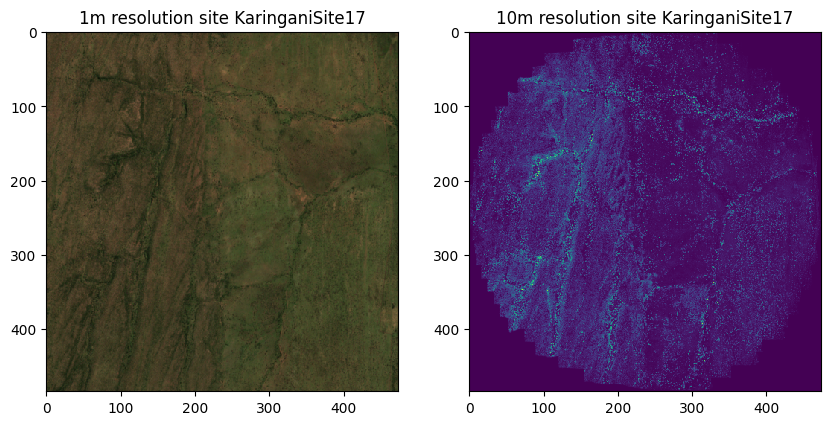

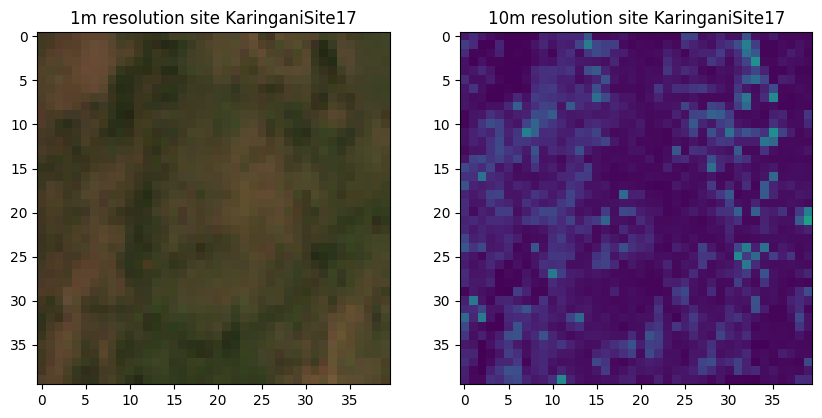

In [36]:
fn_img = f'../data/int/sentinel/sentinel_by_site_32736_10m/KaringaniSite17/T36JUT_20230418T073611_TCI_10m.tif'
with rasterio.open(fn_img) as f:
    print(f.res)
    print(f.crs)
    img = f.read()
    print(f.shape)
    print(f.bounds)

buffer = 40
fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(img[:3,buffer:-buffer,buffer:-buffer].clip(0).transpose(1,2,0), interpolation='none', vmin=0, vmax=15)
ax[1].imshow(d2[0], interpolation='none', vmin=0, vmax=15)
ax[0].set_title(f'1m resolution site {example_site}')
ax[1].set_title(f'10m resolution site {example_site}');

fig, ax = plt.subplots(1,2,figsize=(10,5))
ax[0].imshow(img[:3,200+buffer:240+buffer,200+buffer:240+buffer].clip(0).transpose(1,2,0), interpolation='none', vmin=0, vmax=15)
ax[1].imshow(d2[0,200:240,200:240], interpolation='none', vmin=0, vmax=15)
ax[0].set_title(f'1m resolution site {example_site}')
ax[1].set_title(f'10m resolution site {example_site}');
